# 02 · Exploratory analysis

What does this business look like before we ask the virality question?
Campaign mix, spend, engagement, the customer base, revenue over time, product economics and
the on-site funnel.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import viz; viz.setup()
pd.set_option("display.width", 160, "display.max_columns", 40)

c = pd.read_csv("../data/processed/campaigns.csv", parse_dates=["campaign_date"])
cu = pd.read_csv("../data/processed/customers.csv", parse_dates=["acquisition_date", "first_purchase_date"])
o = pd.read_csv("../data/processed/orders.csv", parse_dates=["order_date"])
s = pd.read_csv("../data/processed/sessions.csv", parse_dates=["timestamp"])
p = pd.read_csv("../data/processed/products.csv", parse_dates=["launch_date"])

## 1. Headline numbers

In [2]:
cm_total = o.contribution_margin.sum()
print(f"campaigns            {len(c):>12,}")
print(f"marketing spend      ${c.spend.sum():>11,.0f}")
print(f"customers acquired   {len(cu):>12,}")
print(f"orders               {len(o):>12,}")
print(f"gross revenue        ${o.gross_revenue.sum():>11,.0f}")
print(f"net revenue          ${o.net_revenue.sum():>11,.0f}")
print(f"contribution margin  ${cm_total:>11,.0f}   ({cm_total / o.net_revenue.sum():.1%} of net revenue)")
print(f"blended CAC          ${c.spend.sum() / len(cu):>11,.2f}")

campaigns                     120
marketing spend      $  1,696,864
customers acquired         40,947
orders                     79,590
gross revenue        $  7,724,838
net revenue          $  7,320,262
contribution margin  $  2,677,038   (36.6% of net revenue)
blended CAC          $      41.44


## 2. Campaign mix and spend

In [3]:
mix = c.groupby("campaign_type").agg(campaigns=("campaign_id", "size"), spend=("spend", "sum"),
                                     reach=("reach", "sum"), avg_discount=("discount_pct", "mean")).sort_values("spend", ascending=False)
mix["spend_share"] = mix.spend / mix.spend.sum()
mix.round(2)

,campaigns,spend,reach,avg_discount,spend_share
campaign_type,,,,,
Paid Amplification,20,648380.37,23300318,7.50,0.38
Influencer,43,639248.35,27175376,6.98,0.38
Discount,15,138550.12,8112411,23.00,0.08
Product Drop,15,131508.73,6379673,0.00,0.08
UGC,11,92590.73,4800953,2.73,0.05
Organic,16,46585.22,3751492,0.00,0.03


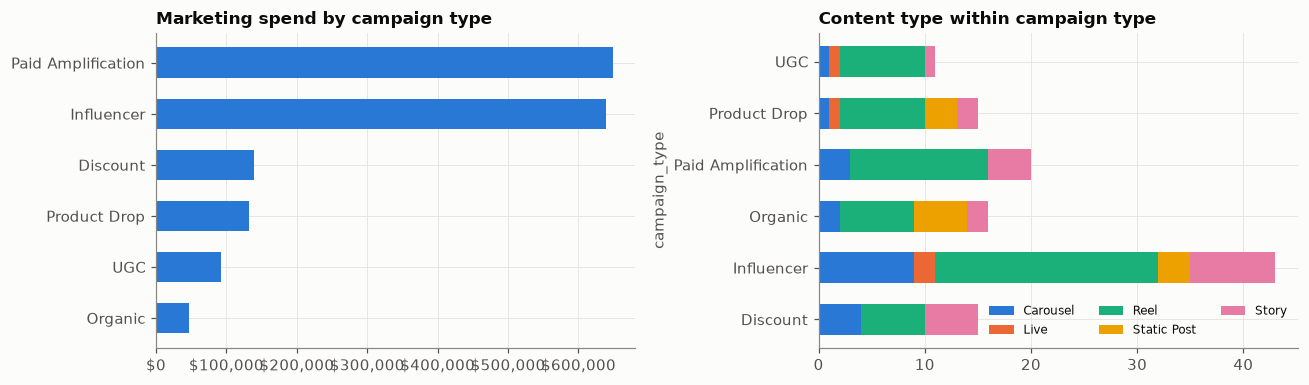

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
m = mix.sort_values("spend")
ax[0].barh(m.index, m.spend, color=viz.SERIES[0], height=0.6); ax[0].xaxis.set_major_formatter(FuncFormatter(viz.money))
ax[0].set_title("Marketing spend by campaign type")
ct = pd.crosstab(c.campaign_type, c.content_type)
ct.plot.barh(stacked=True, ax=ax[1], width=0.6, color=viz.SERIES[:5]); ax[1].set_title("Content type within campaign type"); ax[1].legend(ncol=3, fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig("../images/02_campaign_mix.png"); plt.show()

## 3. Does spend buy reach?

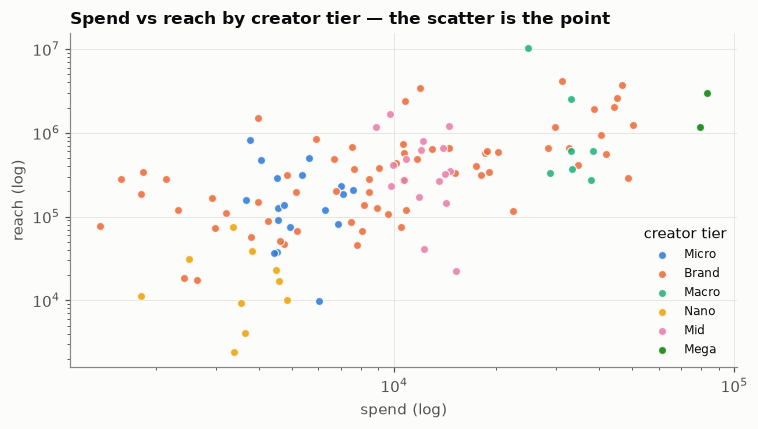

Spearman(spend, reach) = 0.64


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for i, t in enumerate(c.creator_tier.unique()):
    d = c[c.creator_tier == t]
    ax.scatter(d.spend, d.reach, s=28, color=viz.SERIES[i], label=t, alpha=0.85, edgecolor=viz.SURFACE, linewidth=0.8)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("spend (log)"); ax.set_ylabel("reach (log)")
ax.set_title("Spend vs reach by creator tier — the scatter is the point"); ax.legend(title="creator tier", fontsize=8)
plt.tight_layout(); plt.savefig("../images/02_spend_vs_reach.png"); plt.show()
print("Spearman(spend, reach) = %.2f" % c[["spend", "reach"]].corr("spearman").iloc[0, 1])

Spend and reach are positively but loosely related: at the same spend, reach varies by more than an
order of magnitude. That variance is what "going viral" means, and it is what the rest of the project studies.

## 4. Engagement rates

In [6]:
rates = c[["share_rate", "save_rate", "engagement_rate"]] * 100
rates.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
share_rate,120.0,0.703,0.612,0.128,0.323,0.470,0.937,4.295
save_rate,120.0,0.881,0.578,0.214,0.394,0.757,1.187,2.837
engagement_rate,120.0,8.029,1.822,4.499,6.588,7.799,9.422,11.966


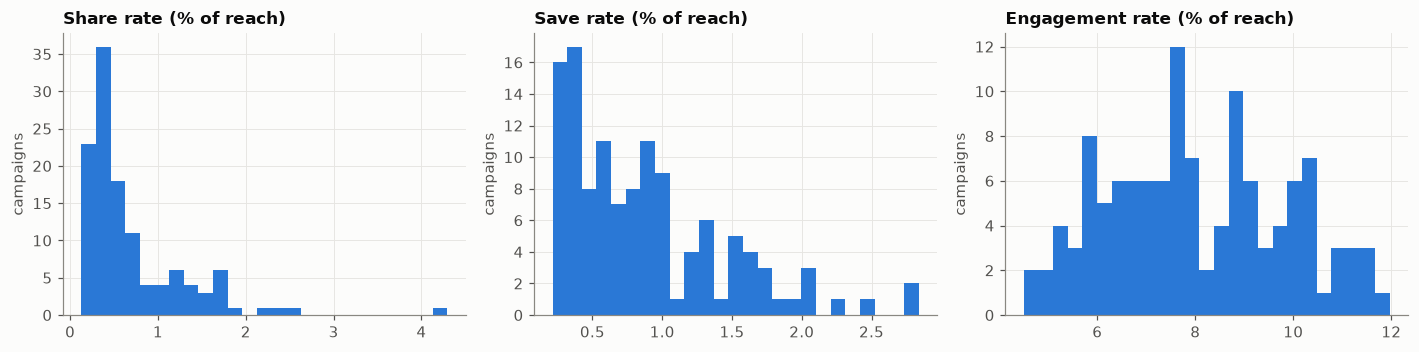

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
for a, col, ttl in zip(ax, ["share_rate", "save_rate", "engagement_rate"], ["Share rate", "Save rate", "Engagement rate"]):
    a.hist(c[col] * 100, bins=25, color=viz.SERIES[0]); a.set_title(f"{ttl} (% of reach)"); a.set_ylabel("campaigns")
plt.tight_layout(); plt.savefig("../images/02_engagement_rates.png"); plt.show()

In [8]:
print("Spearman correlation between share rate and save rate: %.2f" % c[["share_rate", "save_rate"]].corr("spearman").iloc[0, 1])
c.groupby("campaign_type")[["share_rate", "save_rate"]].mean().mul(100).round(3)

Spearman correlation between share rate and save rate: -0.57


,share_rate,save_rate
campaign_type,,
Discount,1.186,0.721
Influencer,0.692,0.770
Organic,0.633,0.818
Paid Amplification,0.737,1.009
Product Drop,0.324,1.379
UGC,0.647,0.712


Sharing and saving are **different behaviours**: they are nearly uncorrelated across campaigns, and
Discount and Organic campaigns get shared most while Product Drops get saved most. Keep that in mind:
both count as "engagement" but they may signal different intent.

## 5. Who are the customers?

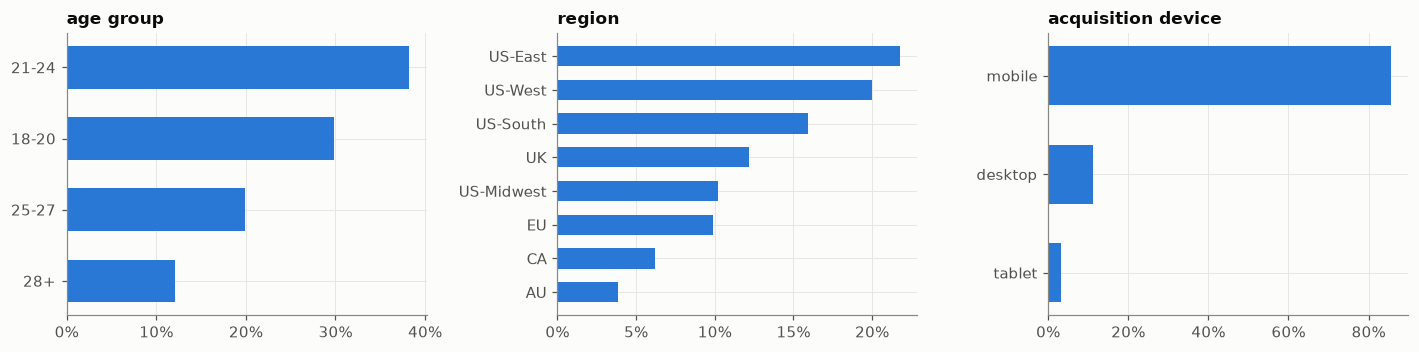

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
for a, col in zip(ax, ["age_group", "region", "acquisition_device"]):
    v = cu[col].value_counts(normalize=True).sort_values()
    a.barh(v.index, v.values, color=viz.SERIES[0], height=0.6); a.xaxis.set_major_formatter(FuncFormatter(viz.pct)); a.set_title(col.replace("_", " "))
plt.tight_layout(); plt.savefig("../images/02_customers.png"); plt.show()

## 6. Revenue over time: spikes follow campaigns

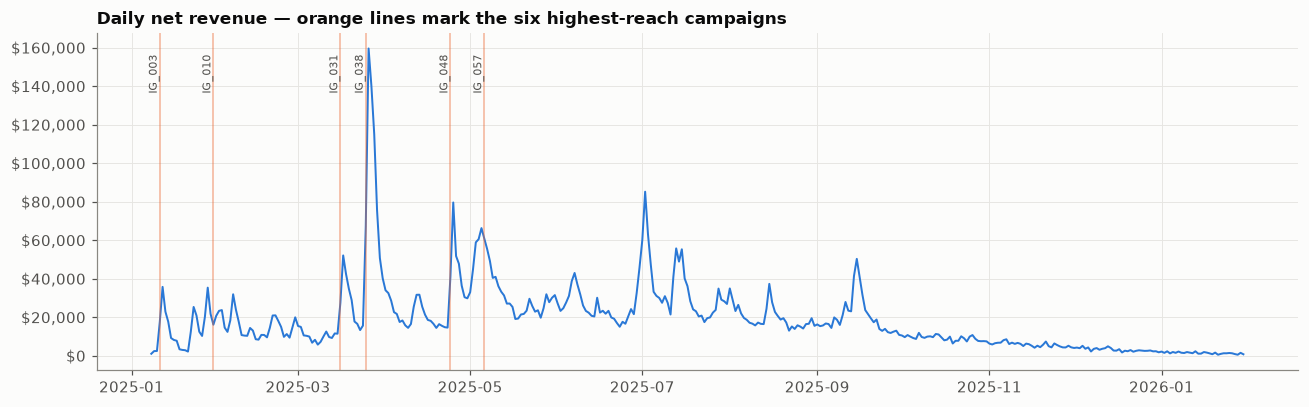

In [10]:
daily = o.set_index("order_date").resample("D").net_revenue.sum()
big = c.nlargest(6, "reach")
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(daily.index, daily.values, color=viz.SERIES[0], linewidth=1.3)
for _, r in big.iterrows():
    ax.axvline(r.campaign_date, color=viz.SERIES[1], alpha=0.5, linewidth=1)
    ax.text(r.campaign_date, daily.max() * 0.98, r.campaign_id, rotation=90, va="top", ha="right", fontsize=7, color=viz.INK2)
ax.yaxis.set_major_formatter(FuncFormatter(viz.money)); ax.set_title("Daily net revenue — orange lines mark the six highest-reach campaigns")
plt.tight_layout(); plt.savefig("../images/02_daily_revenue.png"); plt.show()

## 7. Product economics

In [11]:
prod = o.groupby("category").agg(orders=("order_id", "size"), net_revenue=("net_revenue", "sum"),
                                 cm=("contribution_margin", "sum"), refund_rate=("is_refunded", "mean"),
                                 aov=("net_revenue", "mean"))
prod["cm_margin"] = prod.cm / prod.net_revenue
prod.sort_values("net_revenue", ascending=False).round(3)

,orders,net_revenue,cm,refund_rate,aov,cm_margin
category,,,,,,
Hoodies,24284,2511629.03,1030588.78,0.097,103.427,0.410
Sneakers,11297,2027079.95,473177.44,0.173,179.435,0.233
Limited Drops,8977,1114676.16,425361.15,0.096,124.170,0.382
Gymwear,13293,790990.68,343168.30,0.083,59.504,0.434
T-shirts,15012,653510.71,290694.38,0.068,43.533,0.445
Accessories,6727,222375.81,114047.64,0.040,33.057,0.513


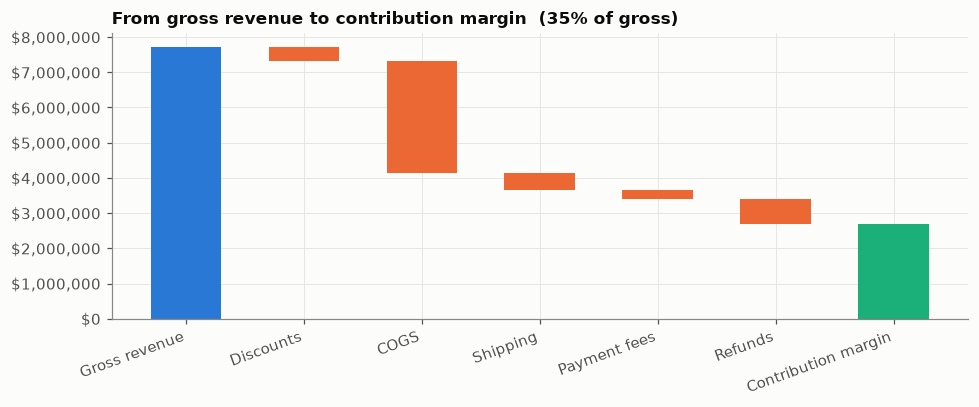

In [12]:
tot = o[["gross_revenue", "discount_amount", "cogs", "shipping_cost", "payment_fee", "refund_amount", "contribution_margin"]].sum()
steps = [("Gross revenue", tot.gross_revenue), ("Discounts", -tot.discount_amount), ("COGS", -tot.cogs),
         ("Shipping", -tot.shipping_cost), ("Payment fees", -tot.payment_fee), ("Refunds", -tot.refund_amount)]
fig, ax = plt.subplots(figsize=(9, 3.8))
run = 0
for i, (lbl, v) in enumerate(steps):
    bottom = run if v >= 0 else run + v
    ax.bar(lbl, abs(v), bottom=bottom, color=viz.SERIES[0] if v >= 0 else viz.SERIES[1], width=0.6)
    run += v
ax.bar("Contribution margin", run, color=viz.SERIES[2], width=0.6)
ax.yaxis.set_major_formatter(FuncFormatter(viz.money)); ax.set_title(f"From gross revenue to contribution margin  ({run / tot.gross_revenue:.0%} of gross)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.savefig("../images/02_margin_waterfall.png"); plt.show()

## 8. On-site funnel (campaign traffic)

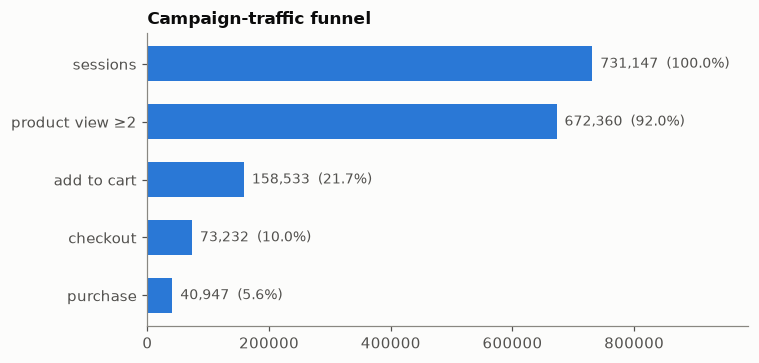

In [13]:
f = s[s.traffic_source == "instagram_campaign"]
funnel = pd.Series({"sessions": len(f), "product view ≥2": (f.product_views >= 2).sum(), "add to cart": f.add_to_cart.sum(),
                    "checkout": f.checkout_started.sum(), "purchase": f.purchase.sum()})
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(funnel.index[::-1], funnel.values[::-1], color=viz.SERIES[0], height=0.6)
for i, (k, v) in enumerate(funnel[::-1].items()):
    ax.text(v, i, f"  {v:,}  ({v / funnel.iloc[0]:.1%})", va="center", fontsize=9, color=viz.INK2)
ax.set_xlim(0, funnel.max() * 1.35); ax.set_title("Campaign-traffic funnel"); ax.grid(False)
plt.tight_layout(); plt.savefig("../images/02_funnel.png"); plt.show()

**Takeaways.** Spend buys reach only loosely; sharing and saving are distinct behaviours; revenue spikes
clearly follow the big campaigns; and roughly a third of gross revenue survives as contribution margin,
which is the number the rest of the project optimises for.